## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Ja-Chan Lu: 

Tianlin Situ:

Julian Luan:

Tony Zhang:

## Data

### Data overview

Dataset #1: `LeagueDashPlayerStats` (NBA Stats API via `nba_api`)
- Purpose: season-level box score stats for all players
- Key fields used: `PLAYER_ID`, `PLAYER_NAME`, `GP`, `MIN`, `FG3A`, `FGA`
- Coverage in this scaffold: representative seasons across all three eras

Dataset #2: `PlayerIndex` (NBA Stats API via `nba_api`)
- Purpose: player profile metadata for merge keys and covariates
- Key fields used: `PERSON_ID`/`PLAYER_ID`, `HEIGHT`, `POSITION`, `FROM_YEAR`, `TO_YEAR`

Join strategy
- Merge season stats to player metadata using `PLAYER_ID`
- Create derived variables: `HEIGHT_IN`, `MPG`, `FG3A_PER_GAME`, `FG3A_PER36`, `FG3A_RATE`
- Add era labels using season year buckets from our research question

Output files produced by code below
- Interim: `data/01-interim/nba_player_season_combined.csv`
- Processed: `data/02-processed/nba_height_3pa_player_season.csv`


In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Run this everytime you load this notebook so the necessary functions can be performed.

import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Setup + reproducible data pull / wrangling scaffold

try:
    from nba_api.stats.endpoints import leaguedashplayerstats, playerindex
except ImportError as exc:
    raise ImportError("Missing dependency `nba_api` in the active notebook kernel.") from exc

warnings.filterwarnings("ignore", category=FutureWarning)

SEASONS = [
    "1996-97", "1999-00", "2004-05", "2008-09", "2012-13", "2016-17", "2020-21", "2023-24"
]
REQUEST_TIMEOUT = 120
MAX_RETRIES = 4
BASE_BACKOFF_SECONDS = 2


def season_to_era(season: str) -> str:
    start_year = int(season.split("-")[0])
    if 1990 <= start_year <= 2000:
        return "1990-2000"
    if 2001 <= start_year <= 2013:
        return "2001-2013"
    return "2014-present"


def parse_height_to_inches(height_value):
    if pd.isna(height_value):
        return np.nan
    if isinstance(height_value, (int, float)):
        return float(height_value)

    s = str(height_value).strip().replace('"', "")
    if "-" in s:
        feet, inches = s.split("-", 1)
        if feet.isdigit() and inches.isdigit():
            return int(feet) * 12 + int(inches)

    try:
        return float(s)
    except ValueError:
        return np.nan


def standardize_position(position_value) -> str:
    if pd.isna(position_value):
        return "Unknown"
    p = str(position_value).upper()
    if "C" in p:
        return "Big"
    if "F" in p:
        return "Wing"
    if "G" in p:
        return "Guard"
    return "Unknown"


def fetch_with_retry(fetch_fn, label: str, retries: int = MAX_RETRIES):
    last_error = None
    for attempt in range(1, retries + 1):
        try:
            return fetch_fn()
        except Exception as exc:
            last_error = exc
            if attempt < retries:
                wait_s = BASE_BACKOFF_SECONDS ** attempt
                print(f"[{label}] attempt {attempt}/{retries} failed: {exc}")
                print(f"Retrying in {wait_s}s...")
                time.sleep(wait_s)
    raise RuntimeError(f"Failed to fetch {label} after {retries} attempts") from last_error


# Pull player metadata and include historical players
player_meta = fetch_with_retry(
    lambda: playerindex.PlayerIndex(historical_nullable=1, timeout=REQUEST_TIMEOUT).get_data_frames()[0].copy(),
    label="PlayerIndex",
)
id_col = "PERSON_ID" if "PERSON_ID" in player_meta.columns else "PLAYER_ID"
height_col = "HEIGHT" if "HEIGHT" in player_meta.columns else "PLAYER_HEIGHT"
position_col = "POSITION" if "POSITION" in player_meta.columns else "PLAYER_POSITION"

meta_cols = [id_col, height_col, position_col]
for optional_col in ["FROM_YEAR", "TO_YEAR"]:
    if optional_col in player_meta.columns:
        meta_cols.append(optional_col)

player_meta = player_meta[meta_cols].rename(
    columns={
        id_col: "PLAYER_ID",
        height_col: "HEIGHT",
        position_col: "POSITION",
    }
)

# Normalize join key types before merge
player_meta["PLAYER_ID"] = pd.to_numeric(player_meta["PLAYER_ID"], errors="coerce").astype("Int64")
player_meta = player_meta.dropna(subset=["PLAYER_ID"]).drop_duplicates(subset=["PLAYER_ID"], keep="last")

# Pull season-level stats for selected seasons
season_frames = []
for season in SEASONS:
    print(f"Pulling season {season}...")
    sdf = fetch_with_retry(
        lambda s=season: leaguedashplayerstats.LeagueDashPlayerStats(
            season=s,
            season_type_all_star="Regular Season",
            per_mode_detailed="Totals",
            timeout=REQUEST_TIMEOUT,
        ).get_data_frames()[0],
        label=f"LeagueDashPlayerStats {season}",
    )

    required_cols = ["PLAYER_ID", "PLAYER_NAME", "GP", "MIN", "FG3A", "FGA"]
    keep_cols = [c for c in required_cols if c in sdf.columns]
    sdf = sdf[keep_cols].copy()
    sdf["PLAYER_ID"] = pd.to_numeric(sdf["PLAYER_ID"], errors="coerce").astype("Int64")
    sdf["SEASON"] = season
    season_frames.append(sdf)
    time.sleep(1.0)

season_stats = pd.concat(season_frames, ignore_index=True)
season_stats = season_stats.dropna(subset=["PLAYER_ID"])

# Merge + feature engineering
df = season_stats.merge(player_meta, on="PLAYER_ID", how="left")

merge_success = df["HEIGHT"].notna().mean()
print(f"Metadata merge success (non-null HEIGHT): {merge_success:.1%}")

# Fallback if merge quality is unexpectedly low
if merge_success < 0.20:
    raise RuntimeError(
        "Metadata merge success is too low (<20%). Check NBA API response schema or connectivity."
    )

df["HEIGHT_IN"] = df["HEIGHT"].apply(parse_height_to_inches)
df["POSITION_GROUP"] = df["POSITION"].apply(standardize_position)
df["ERA"] = df["SEASON"].apply(season_to_era)

df["MPG"] = df["MIN"] / df["GP"].replace(0, np.nan)
df["FG3A_PER_GAME"] = df["FG3A"] / df["GP"].replace(0, np.nan)
df["FG3A_PER36"] = df["FG3A"] / (df["MIN"] / 36).replace(0, np.nan)
df["FG3A_RATE"] = df["FG3A"] / df["FGA"].replace(0, np.nan)

# Data quality filters from project plan
df = df[(df["GP"] >= 41) & (df["MPG"] >= 10)].copy()

# Save outputs for reproducibility
os.makedirs("data/01-interim", exist_ok=True)
os.makedirs("data/02-processed", exist_ok=True)

interim_path = "data/01-interim/nba_player_season_combined.csv"
processed_path = "data/02-processed/nba_height_3pa_player_season.csv"

df.to_csv(interim_path, index=False)
df.to_csv(processed_path, index=False)

print(f"Saved interim dataset: {interim_path}")
print(f"Saved processed dataset: {processed_path}")
print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")

df.head()


Pulling season 1996-97...
Pulling season 1999-00...
Pulling season 2004-05...
Pulling season 2008-09...
Pulling season 2012-13...
Pulling season 2016-17...
Pulling season 2020-21...
Pulling season 2023-24...
Metadata merge success (non-null HEIGHT): 100.0%
Saved interim dataset: data/01-interim/nba_player_season_combined.csv
Saved processed dataset: data/02-processed/nba_height_3pa_player_season.csv
Rows: 2,523 | Columns: 18


,PLAYER_ID,PLAYER_NAME,GP,MIN,FG3A,FGA,SEASON,HEIGHT,POSITION,FROM_YEAR,TO_YEAR,HEIGHT_IN,POSITION_GROUP,ERA,MPG,FG3A_PER_GAME,FG3A_PER36,FG3A_RATE
0,920,A.C. Green,83,2494.298333,20,484,1996-97,6-9,F,1985,2000,81,Wing,1990-2000,30.051787,0.240964,0.288658,0.041322
1,243,Aaron McKie,83,1623.911667,103,365,1996-97,6-5,G,1994,2006,77,Guard,1990-2000,19.565201,1.240964,2.283375,0.282192
3,768,Acie Earl,47,500.141667,5,179,1996-97,6-11,F-C,1993,1996,83,Big,1990-2000,10.641312,0.106383,0.359898,0.027933
4,228,Adam Keefe,62,916.788333,1,160,1996-97,6-9,F,1992,2000,81,Wing,1990-2000,14.786909,0.016129,0.039268,0.006250
5,154,Adrian Caldwell,45,571.608333,2,92,1996-97,6-8,F,1989,1997,80,Wing,1990-2000,12.702407,0.044444,0.125960,0.021739


### Dataset #1: Player-Season Stats + Player Metadata (NBA API)

This checkpoint uses two official NBA Stats API endpoint families exposed through `nba_api`:
1. `LeagueDashPlayerStats` for per-season player statistics (including total 3-point attempts).
2. `PlayerIndex` for player profile attributes (height and listed position).

Wrangling steps implemented in code
- Pull representative seasons across our three eras.
- Keep analysis variables needed for our research question (`FG3A`, `FGA`, `GP`, `MIN`, `HEIGHT`, `POSITION`).
- Merge on player identifier.
- Convert height strings (for example, `6-7`) into inches.
- Create standardized position groups and era labels.
- Create usage-normalized metrics (`FG3A_PER_GAME`, `FG3A_PER36`, and `FG3A_RATE`).
- Apply participation filters (`GP >= 41`, `MPG >= 10`) to reduce noise from tiny samples.

The resulting dataframe is saved to `data/02-processed/nba_height_3pa_player_season.csv` and becomes the canonical analysis table for EDA/modeling.

In [4]:
import sys
sys.path.append('./modules')

from data_quality import checkpoint_summary

summary = checkpoint_summary(df)
summary

{'rows': 2523,
 'cols': 18,
 'duplicate_rows': 0,
 'missing_by_col': {'PLAYER_ID': 0,
  'PLAYER_NAME': 0,
  'GP': 0,
  'MIN': 0,
  'FG3A': 0,
  'FGA': 0,
  'SEASON': 0,
  'HEIGHT': 0,
  'POSITION': 0,
  'FROM_YEAR': 0,
  'TO_YEAR': 0,
  'HEIGHT_IN': 0,
  'POSITION_GROUP': 0,
  'ERA': 0,
  'MPG': 0,
  'FG3A_PER_GAME': 0,
  'FG3A_PER36': 0,
  'FG3A_RATE': 0}}

### Dataset #2: Optional Extension Dataset (Not Required for This Checkpoint)

For this checkpoint, we use the merged player-season table above as our analysis-ready dataset.
If we later add team-context controls (pace, offensive rating, etc.), they will be joined as a separate dataset in this section.


In [5]:
# Additional validation checks for checkpoint reporting
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("Top missingness percentages:")
print(missing_pct.head(10))

suspicious_heights = df[(df["HEIGHT_IN"] < 65) | (df["HEIGHT_IN"] > 90)]
print(f"Suspicious height rows (<65 or >90 inches): {len(suspicious_heights)}")

era_position_counts = (
    df.groupby(["ERA", "POSITION_GROUP"], dropna=False)
      .size()
      .reset_index(name="n_player_seasons")
      .sort_values(["ERA", "POSITION_GROUP"])
)
era_position_counts

Top missingness percentages:
PLAYER_ID      0.0
PLAYER_NAME    0.0
GP             0.0
MIN            0.0
FG3A           0.0
FGA            0.0
SEASON         0.0
HEIGHT         0.0
POSITION       0.0
FROM_YEAR      0.0
dtype: float64
Suspicious height rows (<65 or >90 inches): 3


,ERA,POSITION_GROUP,n_player_seasons
0,1990-2000,Big,156
1,1990-2000,Guard,198
2,1990-2000,Wing,235
3,2001-2013,Big,247
4,2001-2013,Guard,322
5,2001-2013,Wing,388
6,2014-present,Big,207
7,2014-present,Guard,378
8,2014-present,Wing,392


In [6]:
suspicious_heights

,PLAYER_ID,PLAYER_NAME,GP,MIN,FG3A,FGA,SEASON,HEIGHT,POSITION,FROM_YEAR,TO_YEAR,HEIGHT_IN,POSITION_GROUP,ERA,MPG,FG3A_PER_GAME,FG3A_PER36,FG3A_RATE
177,49,Gheorghe Muresan,73,1841.985000,0,541,1996-97,7-7,C,1993,1999,91,Big,1990-2000,25.232671,0.000000,0.00000,0.000000
316,177,Muggsy Bogues,65,1877.030000,144,443,1996-97,5-3,G,1987,2000,63,Guard,1990-2000,28.877385,2.215385,2.76181,0.325056
747,177,Muggsy Bogues,80,1729.986667,51,358,1999-00,5-3,G,1987,2000,63,Guard,1990-2000,21.624833,0.637500,1.06128,0.142458


The players displayed as suspicious heights are to be kept in the dataset as these 2 specific players are considered outliers in the league. Gheroghe Muresan and Muggsy Bogues happen to be the league's tallest/shortest players to ever play in the NBA, so therefore these rows are to be kept in our dataset for analysis.

In [7]:
# Cell for outputting wrangled data frame that saved into csv file so you do not have to run 
# the data wrangling process again everytime the notebook is opened up.
wrangled_df = pd.read_csv('data/02-processed/nba_height_3pa_player_season.csv')
wrangled_df

,PLAYER_ID,PLAYER_NAME,GP,MIN,FG3A,FGA,SEASON,HEIGHT,POSITION,FROM_YEAR,TO_YEAR,HEIGHT_IN,POSITION_GROUP,ERA,MPG,FG3A_PER_GAME,FG3A_PER36,FG3A_RATE
0,920,A.C. Green,83,2494.298333,20,484,1996-97,6-9,F,1985,2000,81,Wing,1990-2000,30.051787,0.240964,0.288658,0.041322
1,243,Aaron McKie,83,1623.911667,103,365,1996-97,6-5,G,1994,2006,77,Guard,1990-2000,19.565201,1.240964,2.283375,0.282192
2,768,Acie Earl,47,500.141667,5,179,1996-97,6-11,F-C,1993,1996,83,Big,1990-2000,10.641312,0.106383,0.359898,0.027933
3,228,Adam Keefe,62,916.788333,1,160,1996-97,6-9,F,1992,2000,81,Wing,1990-2000,14.786909,0.016129,0.039268,0.006250
4,154,Adrian Caldwell,45,571.608333,2,92,1996-97,6-8,F,1989,1997,80,Wing,1990-2000,12.702407,0.044444,0.125960,0.021739
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2518,1628976,Wendell Carter Jr.,55,1406.303333,171,425,2023-24,6-10,C-F,2018,2025,82,Big,2014-present,25.569152,3.109091,4.377434,0.402353
2519,1630214,Xavier Tillman,54,974.555000,81,279,2023-24,6-8,F,2020,2025,80,Wing,2014-present,18.047315,1.500000,2.992135,0.290323
2520,1628380,Zach Collins,69,1525.728333,181,616,2023-24,6-9,F-C,2017,2025,81,Big,2014-present,22.112005,2.623188,4.270747,0.293831
2521,1630533,Ziaire Williams,51,1037.681667,189,378,2023-24,6-9,F,2021,2025,81,Wing,2014-present,20.346699,3.705882,6.556924,0.500000


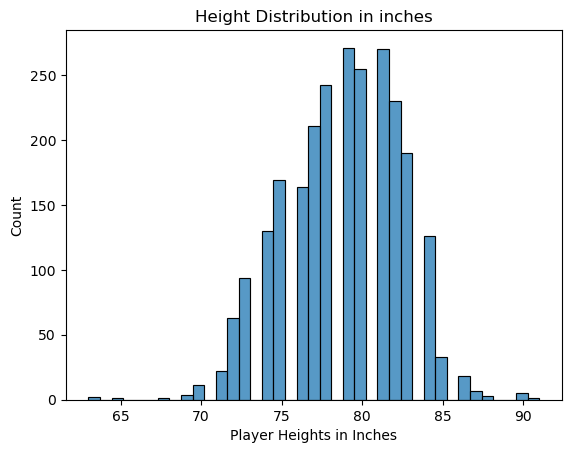

In [8]:
# Distribution of Height Variable
sns.histplot(wrangled_df['HEIGHT_IN'])
plt.title('Height Distribution in inches')
plt.xlabel('Player Heights in Inches')
plt.ylabel('Count')
plt.show()

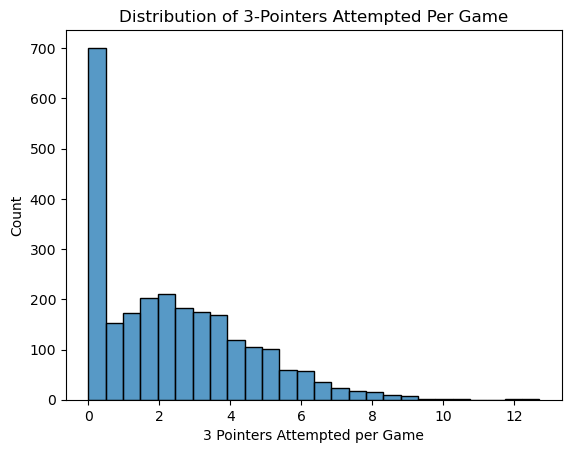

In [9]:
# Distribution of 3PA Per Game Variable
sns.histplot(wrangled_df['FG3A_PER_GAME'])
plt.title('Distribution of 3-Pointers Attempted Per Game')
plt.xlabel('3 Pointers Attempted per Game')
plt.ylabel('Count')
plt.show()

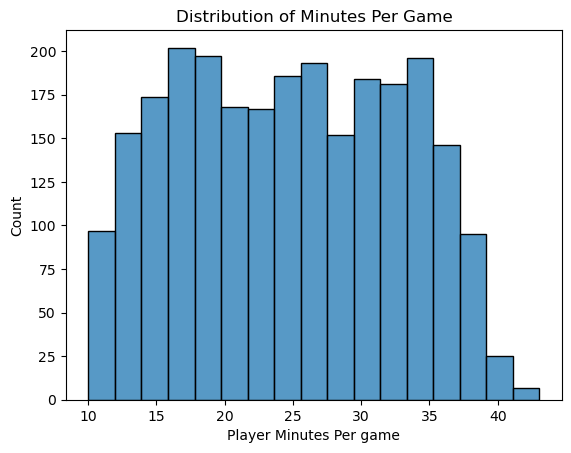

In [10]:
# Distribution of Minutes Per Game Variable
sns.histplot(wrangled_df['MPG'])
plt.title('Distribution of Minutes Per Game')
plt.xlabel('Player Minutes Per game')
plt.ylabel('Count')
plt.show()

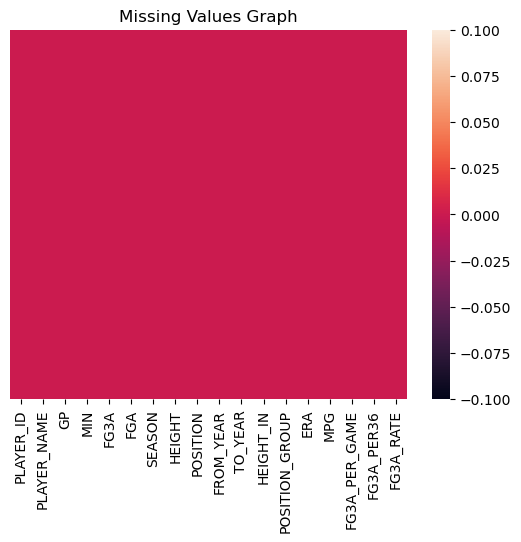

In [11]:
# Missing Values Graph
sns.heatmap(wrangled_df.isnull(), yticklabels=False)
plt.title('Missing Values Graph')
plt.show()

The heatmap shown above has a color for missing data and another color for when the data is not missing. Therefore, the uniform color demonstrates that every single cell in the dataset has a value (no missing data).

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

##### Distribution of Heights

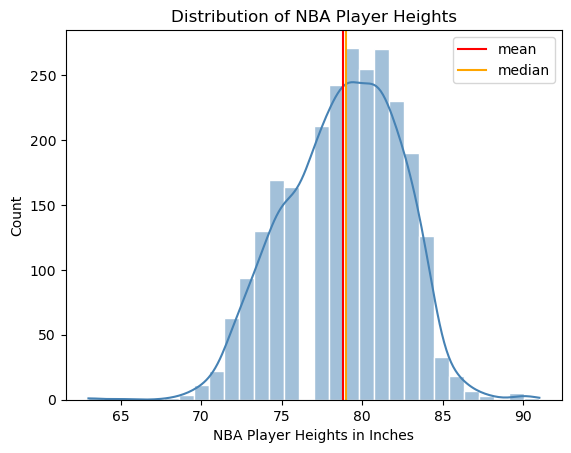

In [12]:
sns.histplot(data=wrangled_df, x='HEIGHT_IN', bins= 30, kde=True, color='steelblue', edgecolor='white')
plt.axvline(wrangled_df['HEIGHT_IN'].mean(), color='red', label='mean')
plt.axvline(wrangled_df['HEIGHT_IN'].median(), color='orange', label='median')
plt.title('Distribution of NBA Player Heights')
plt.xlabel('NBA Player Heights in Inches')
plt.legend()
plt.show()

The histogram shows the distribution of NBA player heights in inches across all 3 eras ranging from 1990-present day. The distribution is approximately normal and centered at around 79 inches which is considered the average height in an NBA roster. As seen on the graph, majority of players fall between 72 inches to 85 inches with 2 extreme outliers being Muggsy Bogues at 63 inches and Gheorghe Mursean at 91 inches.  

##### Grouping by Player Positions

In [13]:
# These are all the unique positions a player can play on the court. 
positions_groups = wrangled_df['POSITION_GROUP'].value_counts()
positions_groups

POSITION_GROUP
Wing     1015
Guard     898
Big       610
Name: count, dtype: int64

,mean,std,min,max
POSITION_GROUP,,,,
Big,82.811475,1.711220,78.0,91.0
Guard,75.095768,2.178174,63.0,80.0
Wing,79.661084,1.597401,76.0,85.0


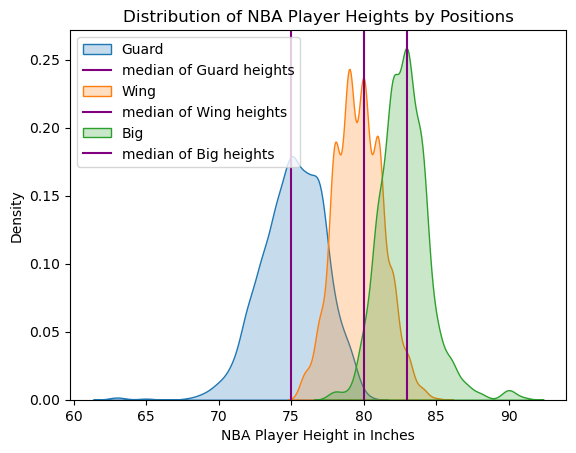

In [14]:
# Plot grouped player heights by positions (guard, wing, center)
for group in ['Guard', 'Wing', 'Big']:
    data = wrangled_df[wrangled_df['POSITION_GROUP'] == group]
    sns.kdeplot(data['HEIGHT_IN'], label=group, fill= True)
    plt.axvline(data['HEIGHT_IN'].median(), color='purple', label=f"median of {group} heights")
plt.title('Distribution of NBA Player Heights by Positions')
plt.xlabel('NBA Player Height in Inches')
plt.legend()

wrangled_df.groupby('POSITION_GROUP')['HEIGHT_IN'].describe()[['mean', 'std','min','max']]

Above is both a dataset consisting of the 3 position groups with the mean, minimum, maximum, standard deviation of player heights as well as a visual representing the distribution of player heights grouped by their positions (Guard, Wing, Big). Additionally, guards are observed to have a median height of 75 inches, wings with 80 inches, and bigs with 83 inches. Despite overlaps in heights between guards, bigs, and wings, since their medians differ enough (up to a 5 inch difference between positions), there is enough distinction for the positions to be considered separate groups to explore our data. Players with the same heights but different positions can have a significantly different magnitude of 3-pointers attempted due to the fact that wings are already positioned on the 3-point line whereas bigs are positioned much further away from the 3-point line and closer to the basket. Guards with the least amount of overlap with any position are considered elite 3-point shooters or elite playmakers as shorter players need to makeup for the gap in physicality with skill in order to excel offensively (shooting or playmaking). 

##### 3 Pointers Attempted by Era

In our wrangled dataframe, we have 3 variables we can use best capture 3-pointers attempted throughout our 3 eras: 
     
     1. FG3A_PER_GAME: Affected by playing time as more playing time allows for more 3-pointer volume
     
     2. FG3A_PER36: 3-pointers attempted per 36 minutes of playtime, allowiong for better comparisons across time as every player is constrained under the unit of 36 minutes playtime)
     
     3. FG3A_RATE: 3-Pointers attempted as a fraction of total shot attempts by a player. 
In our analysis of eras, FG3A_RATE is the choice we went with as the metric properly displayed how much each individual player relied on 3-pointers as part of their play-style, and was independent of playstyles across eras and playing time. 

In [19]:
wrangled_df.groupby('ERA')['FG3A_RATE'].median()

ERA
1990-2000       0.147453
2001-2013       0.206629
2014-present    0.391960
Name: FG3A_RATE, dtype: float64

In [18]:
wrangled_df.groupby('SEASON')['FG3A_RATE'].median()

SEASON
1996-97    0.191064
1999-00    0.127820
2004-05    0.168558
2008-09    0.196262
2012-13    0.243316
2016-17    0.328307
2020-21    0.418959
2023-24    0.422348
Name: FG3A_RATE, dtype: float64

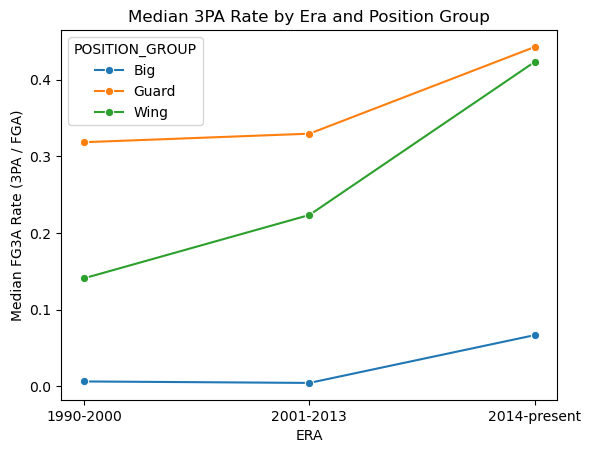

In [42]:
by_era = wrangled_df.groupby(['ERA', 'POSITION_GROUP'])['FG3A_RATE'].median().reset_index()
sns.lineplot(data=by_era, x='ERA', y='FG3A_RATE', hue='POSITION_GROUP', marker='o')
plt.title('Median 3PA Rate by Era and Position Group')
plt.xlabel('ERA')
plt.ylabel('Median FG3A Rate (3PA / FGA)')
plt.show()

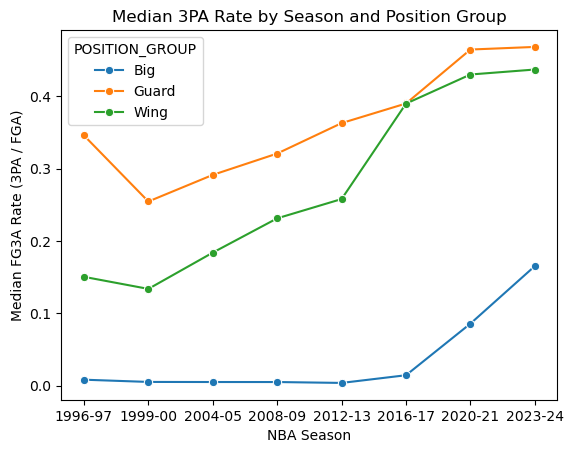

In [43]:
by_season = wrangled_df.groupby(['SEASON', 'POSITION_GROUP'])['FG3A_RATE'].median().reset_index()
sns.lineplot(data=by_season, x='SEASON', y='FG3A_RATE', hue='POSITION_GROUP', marker='o')
plt.title('Median 3PA Rate by Season and Position Group')
plt.xlabel('NBA Season')
plt.ylabel('Median FG3A Rate (3PA / FGA)')
plt.show()

Instead of mean rate of 3-pointers attempted, we used the median as our dataset is heavily right skewed as seen with the Distribution of 3-Pointers Attempted Per Game figure and utilizing the median of skewed data gives us a better measure for its central tendency.

Additionally we grouped the data by season instead of ERAS as grouping by eras will only give us the average rate of 3-pointers attempted by position by era, which is only 3 datapoints per era where as grouping by season gave us 8 pointers per position group, giving us more data to work with. 

The figures reveal a consistent rise in the rate of 3-pointers attempted across all position groups throughout the seasons. Guards started out with high-volume 3-pointers attempted, whereas wings started a much lower volume and saw a steady increase in rate, but the most shocking discovery was the change Bigs went through. Bigs which attempted close to 0 3-pointers in earlier seasons, saw a sharp rise in the rate of 3-pointers attempted. This information reveals that the negative relationship between player height and 3-pointers attempted we hypothesized earlier may be weakening.  

Commentary: ...